# 15b visualize A + R_eff surrogate

Dvorkin-Smith の Eq.(77), Eq.(78) を意識した surrogate を可視化する notebook です。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
RESULT = ROOT / 'results/15-a-reff-surrogate'
shapes = pd.read_csv(RESULT / 'surrogate_shapes.csv')
summary = pd.read_csv(RESULT / 'surrogate_bound_summary.csv')
summary.head()


,mass_eV,tau,delta_y,b,Rbar_Mpc,siglnR,A_model,z_re,Reff_Mpc,L_peak_surrogate,siglnL_surrogate,D_peak_surrogate,A_tau_eff,max_patchy_budget_fraction,L_at_max_fraction,min_scale_factor_to_fit
0,2.030918e-27,0.068,14.7,1.0,5.0,0.409,0.053877,9.638259,9.762631,978.106830,0.409,0.000019,2.002807e+14,1.370339e+21,100,7.297467e-22
1,5.878016e-27,0.068,14.7,1.0,5.0,0.409,0.053877,9.638259,9.762631,978.106830,0.409,0.000019,2.020277e+14,1.394350e+21,100,7.171799e-22
2,1.000000e-26,0.068,14.7,1.0,5.0,0.409,0.053877,9.638259,9.762631,978.106830,0.409,0.000019,-3.390683e+13,3.927572e+19,100,2.546102e-20
3,2.030918e-27,0.068,14.7,1.0,5.0,0.541,0.053877,9.638259,16.121631,592.303337,0.541,0.000019,2.002807e+14,3.466140e+25,100,2.885054e-26
4,5.878016e-27,0.068,14.7,1.0,5.0,0.541,0.053877,9.638259,16.121631,592.303337,0.541,0.000019,2.020277e+14,3.526875e+25,100,2.835371e-26


## Surrogate amplitude $A(\tau, \Delta y)$ and $R_{\rm eff}$ summary

In [2]:
cols = ['tau','delta_y','b','Rbar_Mpc','siglnR','A_model','z_re','Reff_Mpc','L_peak_surrogate','D_peak_surrogate']
summary[cols].drop_duplicates().sort_values(cols[:5]).head(20)


,tau,delta_y,b,Rbar_Mpc,siglnR,A_model,z_re,Reff_Mpc,L_peak_surrogate,D_peak_surrogate
0,0.068,14.7,1.0,5.0,0.409,0.053877,9.638259,9.762631,978.106830,0.000019
3,0.068,14.7,1.0,5.0,0.541,0.053877,9.638259,16.121631,592.303337,0.000019
6,0.068,14.7,1.0,5.0,0.693,0.053877,9.638259,34.138778,279.708194,0.000019
9,0.068,14.7,1.0,6.0,0.409,0.053877,9.638259,11.715157,815.089025,0.000019
12,0.068,14.7,1.0,6.0,0.541,0.053877,9.638259,19.345957,493.586114,0.000019
15,0.068,14.7,1.0,6.0,0.693,0.053877,9.638259,40.966533,233.090162,0.000019
18,0.068,14.7,1.0,8.0,0.409,0.053877,9.638259,15.620209,611.316769,0.000019
21,0.068,14.7,1.0,8.0,0.541,0.053877,9.638259,25.794610,370.189586,0.000019
24,0.068,14.7,1.0,8.0,0.693,0.053877,9.638259,54.622044,174.817622,0.000019
27,0.068,14.7,2.0,5.0,0.409,0.053877,9.638259,9.762631,978.106830,0.000038


## Example surrogate shapes

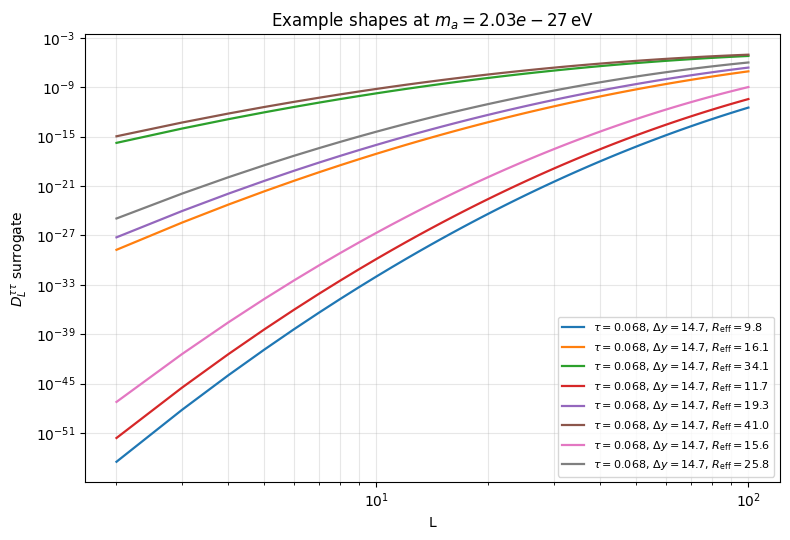

In [5]:
mass0 = sorted(summary['mass_eV'].unique())[0]
sub = summary[summary['mass_eV'] == mass0].drop_duplicates(['tau','delta_y','b','Rbar_Mpc','siglnR']).head(8)
fig, ax = plt.subplots(figsize=(8,5.5))
for _, row in sub.iterrows():
    grp = shapes[(shapes['tau']==row['tau']) & (shapes['delta_y']==row['delta_y']) & (shapes['b']==row['b']) & (shapes['Rbar_Mpc']==row['Rbar_Mpc']) & (shapes['siglnR']==row['siglnR'])]
    label = rf"$\tau={row.tau:.3f},\,\Delta y={row.delta_y:g},\,R_{{\rm eff}}={row.Reff_Mpc:.1f}$"
    ax.loglog(grp['L'], grp['D_shape'], lw=1.6, label=label)
ax.set_xlabel('L')
ax.set_ylabel(r'$D_L^{\tau\tau}$ surrogate')
ax.set_title(fr'Example shapes at $m_a={mass0:.2e}\,{{\rm eV}}$')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Required down-scaling to fit the anisotropic-CB budget

/tmp/ipykernel_41396/1982132510.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


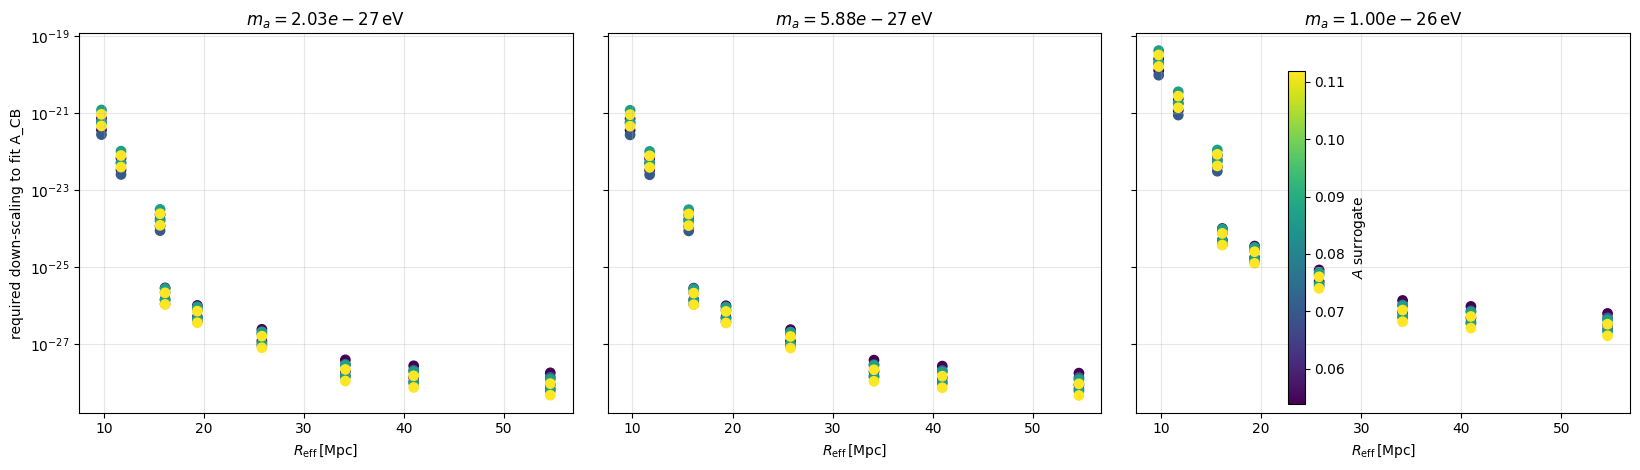

In [6]:
masses = sorted(summary['mass_eV'].unique())
fig, axes = plt.subplots(1, len(masses), figsize=(5.5*len(masses), 4.8), sharey=True)
if len(masses) == 1:
    axes = [axes]
for ax, mass in zip(axes, masses):
    sub = summary[summary['mass_eV'] == mass]
    sc = ax.scatter(sub['Reff_Mpc'], sub['min_scale_factor_to_fit'], c=sub['A_model'], cmap='viridis', s=45)
    ax.set_yscale('log')
    ax.set_xlabel(r'$R_{\rm eff}\,[{\rm Mpc}]$')
    ax.set_title(fr'$m_a={mass:.2e}\,{{\rm eV}}$')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('required down-scaling to fit A_CB')
cbar = fig.colorbar(sc, ax=axes, shrink=0.9)
cbar.set_label(r'$A$ surrogate')
plt.tight_layout()
plt.show()


## Strongest and weakest combinations

In [7]:
rows = []
for mass in masses:
    sub = summary[summary['mass_eV'] == mass].copy()
    strongest = sub.loc[sub['min_scale_factor_to_fit'].idxmin()]
    weakest = sub.loc[sub['min_scale_factor_to_fit'].idxmax()]
    rows.append({
        'mass_eV': mass,
        'strongest_scale_limit': strongest['min_scale_factor_to_fit'],
        'strongest_tau': strongest['tau'],
        'strongest_delta_y': strongest['delta_y'],
        'strongest_b': strongest['b'],
        'strongest_Reff_Mpc': strongest['Reff_Mpc'],
        'weakest_scale_limit': weakest['min_scale_factor_to_fit'],
        'weakest_tau': weakest['tau'],
        'weakest_delta_y': weakest['delta_y'],
        'weakest_b': weakest['b'],
        'weakest_Reff_Mpc': weakest['Reff_Mpc'],
    })
pd.DataFrame(rows)


,mass_eV,strongest_scale_limit,strongest_tau,strongest_delta_y,strongest_b,strongest_Reff_Mpc,weakest_scale_limit,weakest_tau,weakest_delta_y,weakest_b,weakest_Reff_Mpc
0,2.030918e-27,4.707526e-29,0.11,19.0,2.0,54.622044,1.206087e-21,0.11,14.7,1.0,9.762631
1,5.878016e-27,4.626459e-29,0.11,19.0,2.0,54.622044,1.185318e-21,0.11,14.7,1.0,9.762631
2,1.000000e-26,1.642466e-27,0.11,19.0,2.0,54.622044,4.208065e-20,0.11,14.7,1.0,9.762631
